# Семинар 7: Вариационный автоэнкодер (VAE) для аудио

На этом занятии мы перейдём от детерминированных сетей к генеративным моделям. Разберём:
1. Математику VAE: ELBO, репараметризационный трюк, KL-дивергенцию.
2. Реализацию Encoder/Decoder с гауссовским латентным пространством.
3. Обучение на задаче реконструкции Mel-признаков (AudioMNIST).
4. Визуализацию латентного пространства и генерацию новых сэмплов из шума.

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm

torch.manual_seed(42)
np.random.seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Device: mps


In [ ]:
%pip install gdown -q

In [ ]:
import gdown
import zipfile

FILE_ID = "13E8JVJdNYS9K9ubdGcruLSMLUD10OLbx"
output = "audio_mnist.zip"

if not os.path.exists(output):
    gdown.download(id=FILE_ID, output=output, quiet=False)

# Распаковка
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(".")

## 1. Подготовка данных и Mel-спектрограммы

Вместо сжатых MFCC мы будем использовать **Mel-спектрограммы** – 2D-тензоры `(n_mels, time)`, сохраняющие частотно-временную структуру звука.
Для стабильного обучения VAE применяем:
1. **Логарифмическое сжатие**: `log(spec + eps)` для подавления резких перепадов амплитуды.
2. **Попиксельную нормализацию**: приведение к нулевому среднему и единичной дисперсии.
3. **Фиксированный размер**: паддинг/кроп до `(128, 96)` для корректной работы свёрток со stride=2.

In [2]:
# Параметры аудио
SAMPLE_RATE = 16000
TARGET_LEN = 16000
N_MELS = 128
TARGET_MEL_TIME = 96  # Должно делиться на 2^3=8 для 3 слоёв Conv с stride=2

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=1024, hop_length=512,
    win_length=1024, n_mels=N_MELS, center=False
).to('cpu')

class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, target_len=TARGET_LEN):
        self.target_len = target_len
        self.files, self.labels = [], []

        speaker_dirs = [d for d in glob.glob(os.path.join(root_dir, "*")) if os.path.isdir(d)]
        for speaker_dir in speaker_dirs:
            for wav in glob.glob(os.path.join(speaker_dir, "*.wav")):
                base = os.path.basename(wav)
                label_str = base.split("_")[0]
                if label_str.isdigit():
                    self.files.append(wav)
                    self.labels.append(int(label_str))
        print(f"Loaded {len(self.files)} files.")
        self.files = np.array(self.files)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        waveform, _ = torchaudio.load(self.files[idx])
        if waveform.shape[1] < self.target_len:
            pad = self.target_len - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad))
        else:
            waveform = waveform[:, :self.target_len]

        # 1. Mel-спектрограмма: (1, n_mels, time)
        mel_spec = mel_transform(waveform)

        # 2. Фиксация временной оси
        if mel_spec.shape[2] < TARGET_MEL_TIME:
            mel_spec = F.pad(mel_spec, (0, TARGET_MEL_TIME - mel_spec.shape[2]))
        else:
            mel_spec = mel_spec[:, :, :TARGET_MEL_TIME]

        # 3. Логарифмическое сжатие и нормализация
        mel_spec = torch.log(mel_spec + 1e-5)
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-8)

        return mel_spec.float().squeeze(0), torch.tensor(self.labels[idx], dtype=torch.long)


DATASET_PATH = './data'
# Загрузка (укажите путь к распакованному датасету)
try:
    full_dataset = AudioMNISTDataset(DATASET_PATH)
except:
    print("Dataset not found. Using dummy loader.")
    full_dataset = torch.utils.data.TensorDataset(torch.randn(1000, 128, 96), torch.randint(0, 10, (1000,)))

train_ds, val_ds = torch.utils.data.random_split(full_dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(42))
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

Loaded 30000 files.


## 2. Математика VAE

В отличие от обычного автоэнкодера, VAE моделирует распределение в латентном пространстве. Мы максимизируем **Evidence Lower Bound (ELBO)**:

$$ \mathcal{L}(\theta, \phi) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction Loss}} - \underbrace{D_{KL}(q_\phi(z|x) \parallel p(z))}_{\text{KL Divergence}} $$

Где:
- $q_\phi(z|x)$: Encoder (аппроксимация апостериорного распределения)
- $p_\theta(x|z)$: Decoder (правдоподобие)
- $p(z) = \mathcal{N}(0, I)$: Априорное распределение (стандартная норма)

**Репараметризационный трюк:** Чтобы градиенты могли протекать через случайное сэмплирование, мы выносим стохастичность за пределы вычислительного графа:
$$ z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I) $$

In [3]:
def reparameterize(mu, logvar):
    """Репараметризационный трюк"""
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

class ConvEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        )

        self.fc_mu = nn.Linear(128 * 16 * 12, latent_dim)
        self.fc_logvar = nn.Linear(128 * 16 * 12, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        logvar = torch.clamp(logvar, min=-10, max=10)

        return mu, logvar

In [4]:
class ConvDecoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 16 * 12)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (B, 64, 32, 24)
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (B, 32, 64, 48)
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)    # -> (B, 1, 128, 96)
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 16, 12)  # Reshape back to feature map
        return self.deconv(h)

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        x_rec = self.decoder(z)
        return x_rec, mu, logvar

LATENT_DIM = 32
model = ConvVAE(latent_dim=LATENT_DIM).to(DEVICE)
print(model)

ConvVAE(
  (encoder): ConvEncoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (fc_mu): Linear(in_features=24576, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=24576, out_features=32, bias=True)
  )
  (decoder): ConvDecoder(
    (fc): Linear(in_features=32, out_features=24576, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3)

## 3. Функция потерь

Для Mel-спектрограмм используем **MSE** (поскольку данные непрерывные и уже нормализованы). KL-дивергенция вычисляется аналитически для двух гауссиан:
$$ D_{KL} = -\frac{1}{2} \sum_{j=1}^{d} (\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1) $$
Итоговый лосс: $\mathcal{L} = \text{MSE}(x, \hat{x}) + \beta \cdot D_{KL}$

In [5]:
def vae_loss(x, x_rec, mu, logvar, beta=0.5):
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(x_rec, x, reduction='sum') / x.size(0)

    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

## 4. Цикл обучения

Обучаем VAE стандартным способом. Логгируем общий лосс, MSE и KL отдельно, чтобы отслеживать **posterior collapse** (когда KL стремится к 0 и модель превращается в обычный автоэнкодер).

In [6]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 15
history = {"total": [], "mse": [], "kl": []}

# === ИСПРАВЛЕНИЕ: Снижаем beta ===
# 0.5 слишком много, модель пытается "схлопнуть" латентное пространство слишком агрессивно.
BETA = 0.05

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_mse, total_kl = 0, 0, 0
    count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
    for x_batch, _ in pbar:
        x_batch = x_batch.unsqueeze(1).to(DEVICE)
        optimizer.zero_grad()

        x_rec, mu, logvar = model(x_batch)

        # Передаем исправленный BETA
        loss, mse, kl = vae_loss(x_batch, x_rec, mu, logvar, beta=BETA)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        total_mse += mse.item()
        total_kl += kl.item()
        count += x_batch.size(0)

    history["total"].append(total_loss / count)
    history["mse"].append(total_mse / count)
    history["kl"].append(total_kl / count)
    print(f"Epoch {epoch+1:02d} | Total: {history['total'][-1]:.4f} | MSE: {history['mse'][-1]:.4f} | KL: {history['kl'][-1]:.4f}")

Epoch 1:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 01 | Total: 22.1783 | MSE: 21.9120 | KL: 5.3268


Epoch 2:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 02 | Total: 10.4382 | MSE: 10.2790 | KL: 3.1834


Epoch 3:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 07 | Total: 8.8818 | MSE: 8.7561 | KL: 2.5159


Epoch 8:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 08 | Total: 8.7545 | MSE: 8.6326 | KL: 2.4373


Epoch 9:   0%|          | 0/375 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Визуализация и генерация

После обучения проверим:
1. Динамику лоссов (убедимся, что KL не схлопнулся в 0).
2. Латентное пространство: спроецируем $z$ через PCA и посмотрим, группируются ли цифры.
3. Генерацию: сэмплируем $z \sim \mathcal{N}(0, I)$ и пропустим через Decoder.

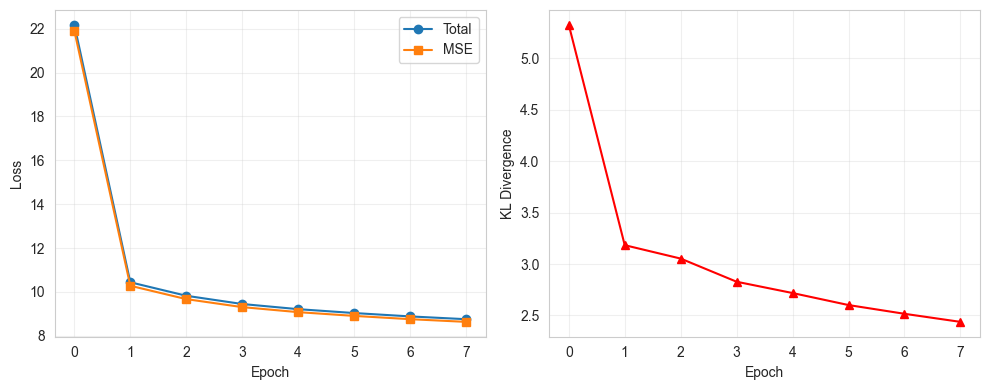

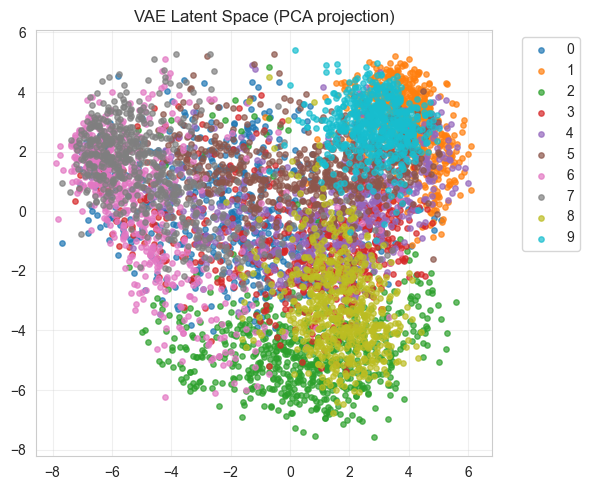

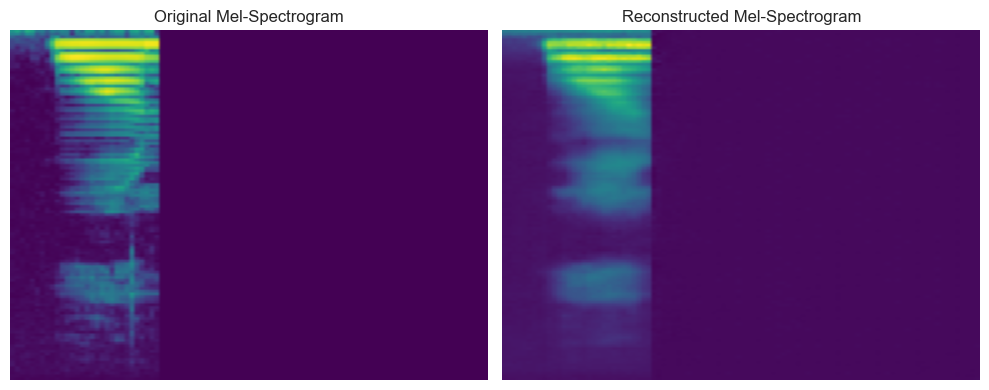

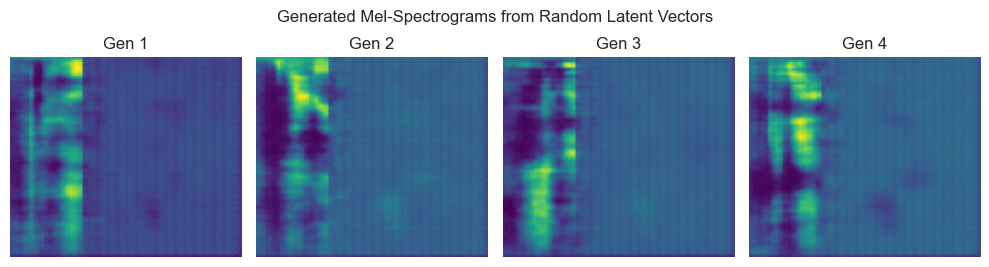

In [8]:
# 1. Графики обучения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["total"], marker="o"); plt.plot(history["mse"], marker="s")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(["Total", "MSE"]); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history["kl"], marker="^", color="red")
plt.xlabel("Epoch"); plt.ylabel("KL Divergence"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Визуализация латентного пространства (PCA)
model.eval()
all_z, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        mu, _ = model.encoder(x_batch.unsqueeze(1).to(DEVICE))
        all_z.append(mu.cpu().numpy())
        all_labels.append(y_batch.numpy())
all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

pca = PCA(n_components=2)
z_2d = pca.fit_transform(all_z)

plt.figure(figsize=(6, 5))
for digit in range(10):
    mask = all_labels == digit
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], label=str(digit), alpha=0.7, s=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("VAE Latent Space (PCA projection)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Original vs Reconstructed
model.eval()
with torch.no_grad():
    sample = val_ds[0][0].unsqueeze(0).unsqueeze(0).to(DEVICE)
    rec, _, _ = model(sample)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample.squeeze().cpu(), cmap="viridis", aspect="auto")
plt.title("Original Mel-Spectrogram"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(rec.squeeze().cpu(), cmap="viridis", aspect="auto")
plt.title("Reconstructed Mel-Spectrogram"); plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Генерация из шума
with torch.no_grad():
    z_rand = torch.randn(4, LATENT_DIM).to(DEVICE)
    x_gen = model.decoder(z_rand)

plt.figure(figsize=(10, 2.5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_gen[i].squeeze().cpu(), cmap="viridis", aspect="auto")
    plt.axis("off")
    plt.title(f"Gen {i+1}")
plt.tight_layout()
plt.suptitle("Generated Mel-Spectrograms from Random Latent Vectors", y=1.05)
plt.show()